## Troponin data
Cardiomyocytes from 46 individuals, each exposed to 5 doxorubicin doses
(0, 0.625, 1.25, 2.5, 5 µM) → 46 × 5 = 230 samples.
One row = one sample (one individual at one dose), not one individual.
`cell_line` = individual, `dosage` = dose, `troponin` = cell damage
(troponin leaks out of damaged heart muscle cells).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

trop = pd.read_csv("data/troponin.txt", sep="\t")
print(trop.shape)
trop.head(10)

(230, 9)


,id,sample,cell_line,dbgap,dosage,cell_line_norep,experiment,troponin,mismatch
0,s001-c64-0.000,s001,c64,6939_48c6,0.000,c64,cTnI_ELISA_8-12-15.xlsx.sheet.1,1.413589,False
1,s002-c64-0.625,s002,c64,6939_48c6,0.625,c64,cTnI_ELISA_8-12-15.xlsx.sheet.1,1.432610,False
2,s003-c64-1.250,s003,c64,6939_48c6,1.250,c64,cTnI_ELISA_8-12-15.xlsx.sheet.1,1.451456,False
3,s004-c64-2.500,s004,c64,6939_48c6,2.500,c64,cTnI_ELISA_8-12-15.xlsx.sheet.1,1.432523,False
4,s005-c64-5.000,s005,c64,6939_48c6,5.000,c64,cTnI_ELISA_8-12-15.xlsx.sheet.1,1.432523,False
5,s006-c41-0.000,s006,c41,c190_4968,0.000,c41,cTnI_ELISA_8-12-15.xlsx.sheet.1,1.754925,False
6,s007-c41-0.625,s007,c41,c190_4968,0.625,c41,cTnI_ELISA_8-12-15.xlsx.sheet.1,1.868967,False
7,s008-c41-1.250,s008,c41,c190_4968,1.250,c41,cTnI_ELISA_8-12-15.xlsx.sheet.1,2.571275,False
8,s009-c41-2.500,s009,c41,c190_4968,2.500,c41,cTnI_ELISA_8-12-15.xlsx.sheet.1,2.476255,False
9,s010-c41-5.000,s010,c41,c190_4968,5.000,c41,cTnI_ELISA_8-12-15.xlsx.sheet.1,2.438300,False


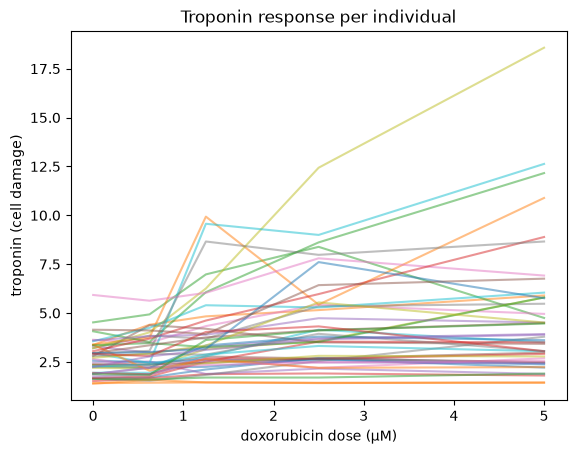

In [16]:
trop_wide = trop.pivot_table(index="cell_line", columns="dosage", values="troponin")
trop_wide.T.plot(legend=False, alpha=0.5)
plt.xlabel("doxorubicin dose (µM)")
plt.ylabel("troponin (cell damage)")
plt.title("Troponin response per individual")
plt.show()

## Gene count data
Same 230 samples, but each was sequenced twice → 460 rows.
The first 10 rows belong to one individual (c64): 5 doses × 2 reads.
Columns: ~19,800 genes (Ensembl IDs, `ENSG...`); each value = how many
RNA fragments of that gene were counted in that sample.
Samples are linked across files by ID: `s001-c64-0.000` (troponin)
= `001-c64-0.000-...` (gene counts) = sample 001, individual c64, dose 0.

In [17]:
import numpy as np

counts = pd.read_csv("data/gene-counts.txt.gz", sep="\t")
print(counts.shape)
counts.iloc[:4, :8]

(460, 19803)


,filename,individual,flow_cell,lane,index,conc,ENSG00000186092,ENSG00000279928
0,001-c64-0.000-HCGYCBBXX-l5,i001,c64,l5,HCGYCBBXX,0.000,0,0
1,001-c64-0.000-HCMYYBBXX-l4,i001,c64,l4,HCMYYBBXX,0.000,0,0
2,002-c64-0.625-HCGYCBBXX-l5,i002,c64,l5,HCGYCBBXX,0.625,0,0
3,002-c64-0.625-HCMYYBBXX-l4,i002,c64,l4,HCMYYBBXX,0.625,0,3


Sum the two sequencing reads of each sample → 230 samples × ~19,800 genes.

In [18]:
genes = [c for c in counts.columns if c.startswith("ENSG")]
sample_id = counts["filename"].str.split("-").str[:3].str.join("-")
X = counts[genes].groupby(sample_id).sum()
print(X.shape)

(230, 19797)


In [19]:
depth = X.sum(axis=1) / 1_000_000
print(depth.sort_values().head(15))
X = X[depth >= 10]
print(X.shape)

filename
045-c15.1-5.000     0.005954
043-c15.1-1.250     0.039762
046-c19.1-0.000     0.051829
074-c11.1-2.500     0.103046
054-c7.2-2.500      0.308705
056-c32-0.000       0.323385
053-c7.2-1.250      0.681766
133-c37-1.250       6.343102
057-c32-0.625       6.721228
081-c17.1-0.000     7.450250
091-c27-0.000       8.930751
134-c37-2.500       9.602468
090-c18-5.000       9.644470
085-c17.1-5.000    10.203063
132-c37-0.625      10.772849
dtype: float64
(217, 19797)


In [20]:
cpm = X.div(X.sum(axis=1), axis=0) * 1_000_000
expressed = (cpm > 1).mean(axis=0) > 0.5
logcpm = np.log2(cpm.loc[:, expressed] + 1)
print(logcpm.shape)

(217, 12342)


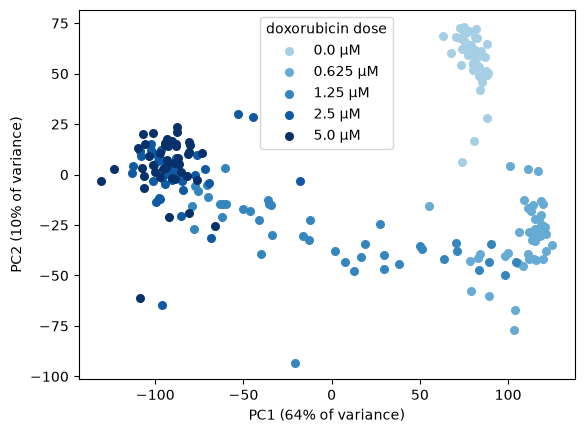

In [21]:
from sklearn.decomposition import PCA

dose = logcpm.index.str.split("-").str[2].astype(float)
pca = PCA(n_components=2)
coords = pca.fit_transform(logcpm)

colors = plt.cm.Blues(np.linspace(0.35, 1.0, 5))
for color, d in zip(colors, sorted(set(dose))):
    mask = (dose == d)
    plt.scatter(coords[mask, 0], coords[mask, 1], color=color, s=30, label=f"{d} µM")
plt.legend(title="doxorubicin dose")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% of variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% of variance)")
plt.show()